<a href="https://colab.research.google.com/github/blood097/Analytics/blob/main/DnD_5e_Monster_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DnD 5e Monster CR prediction**

Data: https://www.kaggle.com/datasets/damom73/dnd-monsters

*This file is a collection of information about monsters from Dungeons and Dragons 5e*

In [1]:
! pip install catboost

In [21]:
! pip install shap

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from catboost import Pool
from catboost import cv
import shap
from sklearn.metrics import mean_absolute_error

## Exploratory data analysis (EDA) and data preprocessing

In [3]:
df = pd.read_csv('/content/monsters.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2435 entries, 0 to 2434
Data columns (total 71 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   slug                    2435 non-null   object 
 1   desc                    770 non-null    object 
 2   name                    2435 non-null   object 
 3   size                    2435 non-null   object 
 4   type                    2435 non-null   object 
 5   subtype                 289 non-null    object 
 6   group                   116 non-null    object 
 7   alignment               1849 non-null   object 
 8   armor_class             2435 non-null   int64  
 9   armor_desc              1375 non-null   object 
 10  hit_points              2435 non-null   int64  
 11  hit_dice                2435 non-null   object 
 12  strength                2435 non-null   int64  
 13  dexterity               2435 non-null   int64  
 14  constitution            2435 non-null   

In [5]:
#Data Reduction
meaningful_features = ['name','size','type','armor_class','hit_points',
                       'strength','dexterity','constitution','intelligence','wisdom','charisma',
                       'cr','legendary_actions',
                       'speed.walk','speed.swim','speed.fly','speed.burrow','speed.climb']

df = df[meaningful_features]

In [6]:
df['speed.walk'] = df['speed.walk'].fillna(0)
df['speed.swim'] = df['speed.swim'].fillna(0)
df['speed.fly'] = df['speed.fly'].fillna(0)
df['speed.burrow'] = df['speed.burrow'].fillna(0)
df['speed.climb'] = df['speed.climb'].fillna(0)

In [7]:
df['legendary_actions'] = np.where(pd.isna(df['legendary_actions']), 0, 1)
df = df.rename(columns={'legendary_actions':'is_legendary'})

In [8]:
df['size'] = df['size'].astype('category')
df['type'] = df['type'].astype('category')
df['is_legendary'] = df['is_legendary'].astype('category')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2435 entries, 0 to 2434
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   name          2435 non-null   object  
 1   size          2435 non-null   category
 2   type          2435 non-null   category
 3   armor_class   2435 non-null   int64   
 4   hit_points    2435 non-null   int64   
 5   strength      2435 non-null   int64   
 6   dexterity     2435 non-null   int64   
 7   constitution  2435 non-null   int64   
 8   intelligence  2435 non-null   int64   
 9   wisdom        2435 non-null   int64   
 10  charisma      2435 non-null   int64   
 11  cr            2435 non-null   float64 
 12  is_legendary  2435 non-null   category
 13  speed.walk    2435 non-null   float64 
 14  speed.swim    2435 non-null   float64 
 15  speed.fly     2435 non-null   float64 
 16  speed.burrow  2435 non-null   float64 
 17  speed.climb   2435 non-null   float64 
dtypes: categ

In [10]:
#Data Splitting
train, test = train_test_split(df,train_size=0.6,random_state=42)
val, test = train_test_split(df,train_size=0.5,random_state=42)

train_full = pd.concat([train,val])

## Modelling

In [11]:
X = ['armor_class','hit_points', 'size','type','is_legendary',
     'strength','dexterity','constitution','intelligence','wisdom','charisma',
     'speed.walk','speed.swim','speed.fly','speed.burrow','speed.climb']

cat_features = ['size','type','is_legendary']

y = ['cr']

In [12]:
params = {'cat_features': cat_features,
              'eval_metric': 'MAE',
              'random_seed':42,
              'learning_rate': 0.3,
              'verbose':100}

In [13]:
model = CatBoostRegressor(**params)

In [14]:
model.fit(train[X],train[y],eval_set=(val[X],val[y]))

0:	learn: 3.1543608	test: 3.0929480	best: 3.0929480 (0)	total: 62.4ms	remaining: 1m 2s
100:	learn: 0.5172408	test: 0.5434111	best: 0.5434111 (100)	total: 446ms	remaining: 3.97s
200:	learn: 0.3619798	test: 0.4187491	best: 0.4186846 (198)	total: 1.35s	remaining: 5.38s
300:	learn: 0.2743399	test: 0.3472871	best: 0.3472871 (300)	total: 2.51s	remaining: 5.82s
400:	learn: 0.2091419	test: 0.2940807	best: 0.2940807 (400)	total: 3.82s	remaining: 5.7s
500:	learn: 0.1694668	test: 0.2649526	best: 0.2649526 (500)	total: 4.98s	remaining: 4.96s
600:	learn: 0.1344823	test: 0.2392505	best: 0.2392505 (600)	total: 5.83s	remaining: 3.87s
700:	learn: 0.1087773	test: 0.2241287	best: 0.2241287 (700)	total: 6.62s	remaining: 2.82s
800:	learn: 0.0889947	test: 0.2112599	best: 0.2112599 (800)	total: 7.13s	remaining: 1.77s
900:	learn: 0.0747446	test: 0.2035306	best: 0.2034497 (898)	total: 7.84s	remaining: 862ms
999:	learn: 0.0632200	test: 0.1971087	best: 0.1968529 (997)	total: 8.68s	remaining: 0us

bestTest = 0.19

In [15]:
new_parameters = {'iterations': model.best_iteration_ + 1,
              'cat_features': cat_features,
              'eval_metric': 'MAE',
              'learning_rate': 0.3,
              'random_seed':42,
              'verbose':100}

In [16]:
model = CatBoostRegressor(**new_parameters)

In [17]:
model.fit(train_full[X],train_full[y])

0:	learn: 3.1717105	total: 8.85ms	remaining: 8.82s
100:	learn: 0.4438178	total: 900ms	remaining: 8s
200:	learn: 0.2835603	total: 1.58s	remaining: 6.26s
300:	learn: 0.1994172	total: 2.28s	remaining: 5.29s
400:	learn: 0.1508467	total: 3.42s	remaining: 5.08s
500:	learn: 0.1184699	total: 4.21s	remaining: 4.18s
600:	learn: 0.0966883	total: 5.03s	remaining: 3.33s
700:	learn: 0.0807362	total: 6.17s	remaining: 2.61s
800:	learn: 0.0688633	total: 7.94s	remaining: 1.95s
900:	learn: 0.0600862	total: 9.07s	remaining: 977ms
997:	learn: 0.0539093	total: 9.96s	remaining: 0us


In [18]:
test['cr_pred'] = model.predict(test[X])

In [19]:
def cr_value(cr_pred):
    if cr_pred >= 0.75:
        return round(cr_pred)
    elif 0.75 > cr_pred >= 0.375:
        return 0.25
    elif 0.375 > cr_pred >= 0.0625:
        return 0.125
    else:
        return 0

test['cr_pred'] = test['cr_pred'].apply(cr_value)

## Model evaluation

In [23]:
print('MAE:', mean_absolute_error(test['cr'],test['cr_pred']))

MAE: 0.7736042692939245


In [24]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(test[X])

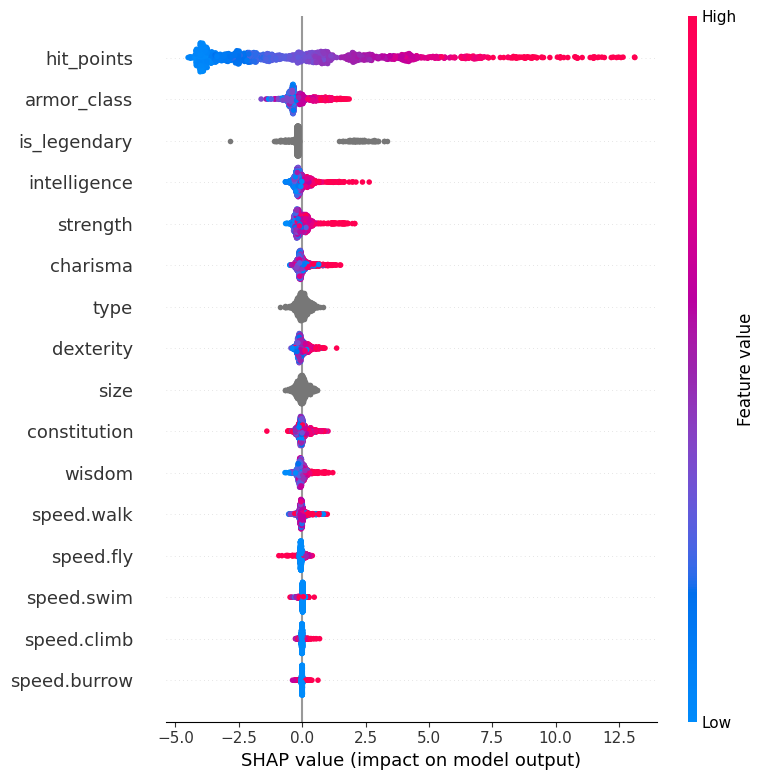

In [25]:
shap.summary_plot(shap_values, test[X])

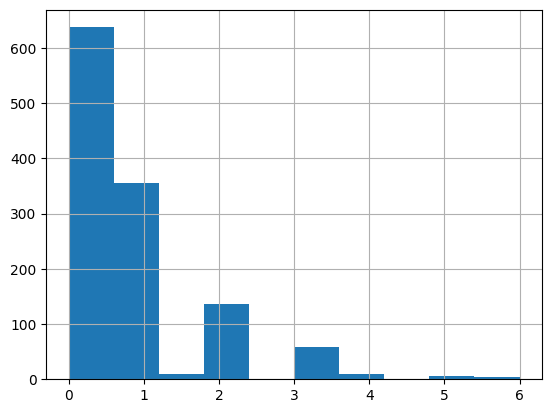

In [27]:
test['error'] = test['cr_pred'] - test['cr']
test['error_abs'] = abs(test['error'])

test['error_abs'].hist();

<Axes: xlabel='cr'>

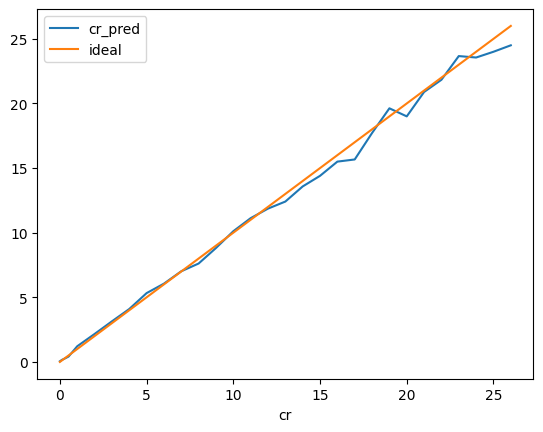

In [67]:

test_plot = test.groupby('cr')['cr_pred'].mean().reset_index()
test_plot['ideal'] = test_plot['cr']
test_plot = test_plot.set_index('cr')
test_plot[['cr_pred','ideal']].plot();